<a href="https://www.pieriandata.com"><img src = "../data/Logo.jpg"></a>
*Copyright by Pierian Data Inc.*

In [12]:
import cv2 as cv 
import numpy as np 
import matplotlib.pyplot as plt

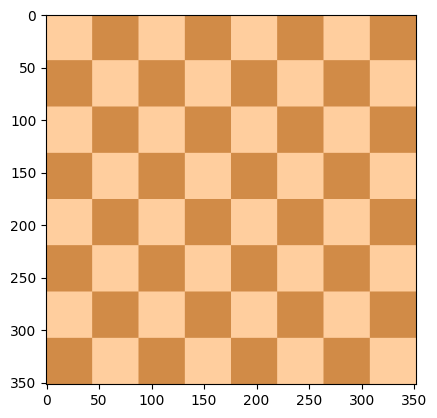

In [13]:
flat_chess= cv.imread("../data/flat_chessboard.png")
flat_chess= cv.cvtColor(flat_chess, cv.COLOR_BGR2RGB)
plt.imshow(flat_chess)

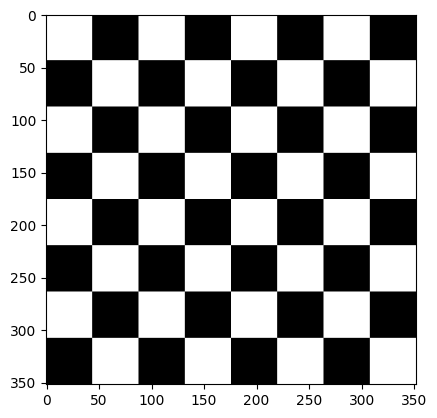

In [14]:
gray_flat_chess = cv.cvtColor(flat_chess, cv.COLOR_BGR2GRAY)
plt.imshow(gray_flat_chess, cmap="gray")

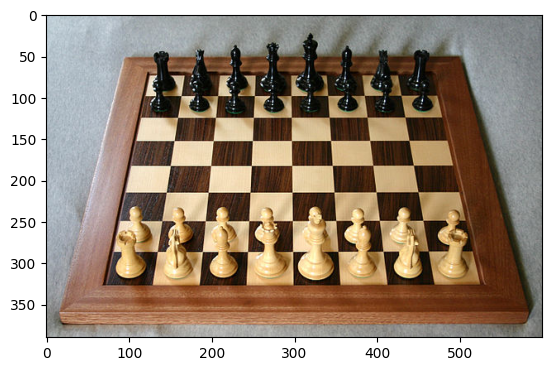

In [15]:
real_chess = cv.imread("../data/real_chessboard.jpg")
real_chess = cv.cvtColor(real_chess, cv.COLOR_BGR2RGB)
plt.imshow(real_chess)

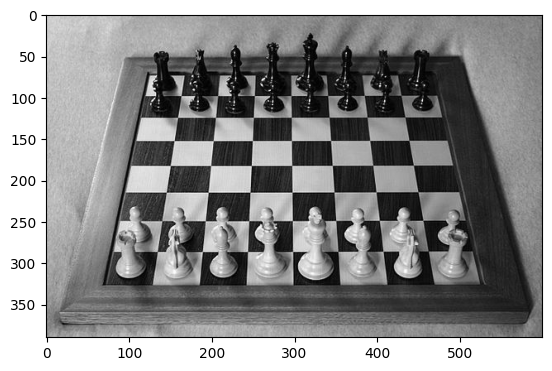

In [16]:
gray_real_chess = cv.cvtColor(real_chess, cv.COLOR_BGR2GRAY)
plt.imshow(gray_real_chess, cmap="gray")

# Harris Corner Detection 

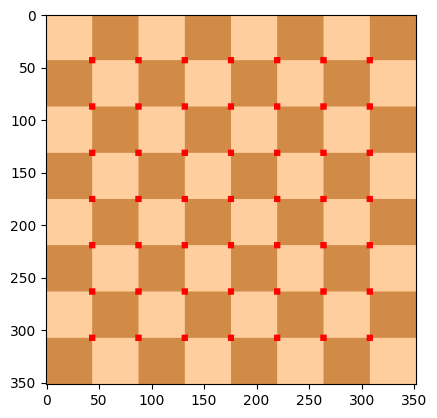

In [21]:
gray = np.float32(gray_flat_chess) #convert to float values sinvce Harris take single channel (gray) and float values

# The block_size parameter is the size of the neighborhood considered for corner detection. 
# A larger block size will result in a more robust corner detection, while a smaller block size will be more sensitive to noise. 
# ksize  is the kernel size for the Sobel operator, which is used to compute the image gradients. 
# A larger kernel size will result in a smoother gradient, while a smaller kernel size will result in a more detailed gradient. 
# while a smaller k value will result in more corners being detected.
# The k parameter is the Harris detector free parameter, which controls the sensitivity of the corner detection. 
# A larger k value will result in fewer corners being detected, 
destination = cv.cornerHarris(src = gray, blockSize=3, ksize=3, k=0.04) 

#dilate the image to reduce the noise and enhance the corner points
destination = cv.dilate(destination, None)

#Threshold 
flat_chess[destination > 0.01 * destination.max()] = [255, 0, 0] #mark the corners in red

plt.imshow(flat_chess)

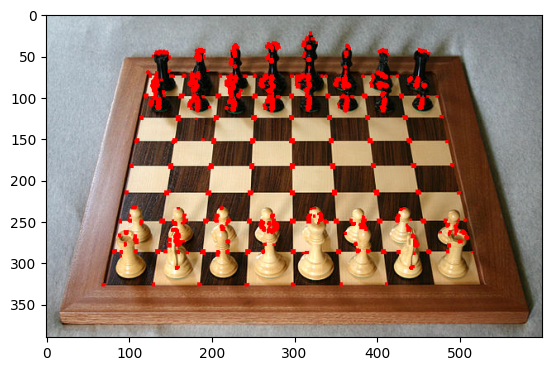

In [22]:
real_gray = np.float32(gray_real_chess)
destination_real = cv.cornerHarris(src = real_gray, blockSize=3, ksize=3, k=0.04)
destination_real = cv.dilate(destination_real, None)
real_chess[destination_real > 0.01 * destination_real.max()] = [255, 0, 0]
plt.imshow(real_chess)